In [1]:
from experiment_common_code import ExperimentResult, plot_metrics_by_group, plot_confusion_matrix, show_plots, ExperimentResult
from common_constants import LANGUAGES, MODEL_NAMES
from icecream import ic

import torch as t

from typing import Literal

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

Load important variables

In [2]:
from experiment_1 import run_experiment_1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probe_type: str = "lr"
num_layers: int | None = None

custom = True
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

ic(custom, model_names, languages, probe_type)

ic| custom: True
    model_names: ['olmo_model']
    languages: ['en']
    probe_type: 'lr'


Using custom configuration


(True, ['olmo_model'], ['en'], 'lr')

Run experiment 1

In [3]:
limited_layers = True
if limited_layers:
    num_layers = 3

force_probe_creation: bool = True

save_results: bool = True

ic(limited_layers, force_probe_creation, save_results)

run_experiment_1(languages, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

ic| limited_layers: True
    force_probe_creation: True
    save_results: True


Running experiment 1 instance. en, control, lr, olmo_model
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_control.pkl
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  [0. 0. 0. ... 0. 1. 1.]
Probing at layer 1
Creating probe
Probe saved to probes\olmo_model\lr_en_layer1_control.pkl
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  [2. 2. 0. ... 2. 1. 0.]
Probing at layer 2
Creating probe
Probe saved to probes\olmo_model\lr_en_layer2_control.pkl
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  [0. 2. 0. ... 2. 2. 2.]
Running experiment 1 instance. en, standard, lr, olmo_model
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_standard.pkl
First few test la

In [ ]:
example_exp_result: ExperimentResult = ExperimentResult.get_from_file(
                        1, "en", "standard", probe_type, "olmo_model"
                    )
print(example_exp_result.metrics["test"].keys())

Make some plots

In [ ]:
# Save plots of all metrics
example_exp_result: ExperimentResult = ExperimentResult.get_from_file(
                        1, "en", "standard", probe_type, "olmo_model"
                    )
all_different_metrics: list[str] = list(example_exp_result.metrics["test"].keys())

save: bool = True

for metric in all_different_metrics:
    if metric == "cm":
        continue

    if "marginal" in metric:
        probing_tasks: list[str] = ["standard"]
    else:
        probing_tasks = ["standard", "control"]
    
    if "per_class" in metric:
        separate_chars_within_plot: list[str] = ["class"]
    else:
        separate_chars_within_plot = ["language", "probing_task"]
    
    print(f"Preparing plot for metric {metric}...")
    show_plots(model_names, 
               ["test", "train"], 
               languages, 
               probing_tasks, 
               probe_type, 
               1, 
               metric, 
               separate_chars_within_plot, 
               save=save, 
               filename=f"experiment1_{metric}" if save else "")

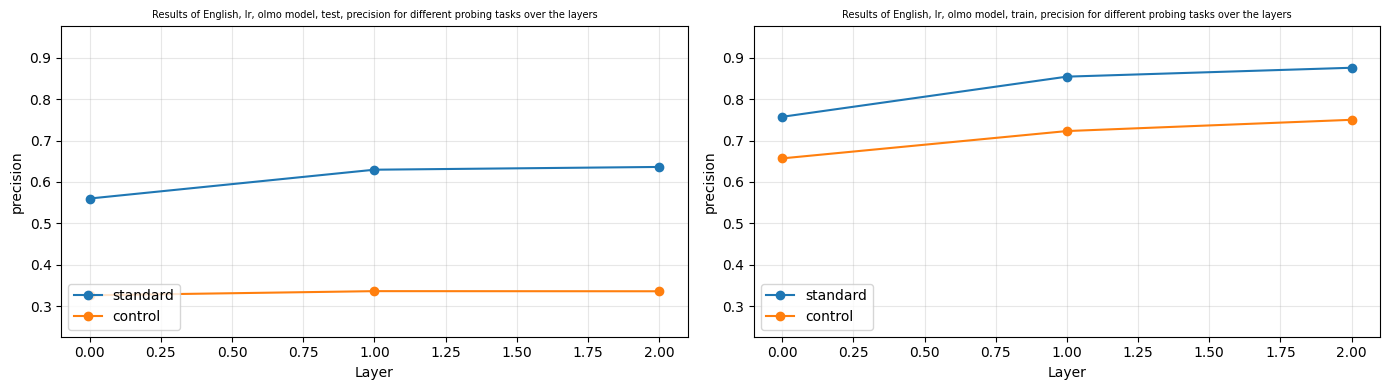

In [4]:
# Get list of plots showing some arbitrary metric
metric = "precision"
show_plots(model_names, ["test", "train"], languages, ["standard", "control"], probe_type, 1, metric)

In [ ]:
# Get list of plots showing per class precision
show_plots(model_names, ["test"], languages, ["standard", "control"], probe_type, 1, "per_class_precision", separate_chars_within_plot=["probing_task", "class"])
show_plots(model_names, ["test"], languages, ["standard"], probe_type, 1, "marginal_per_class_precision", separate_chars_within_plot=["probing_task", "class"])

In [ ]:
# Get list of plots showing accuracy
show_plots(model_names, ["test", "train"], languages, ["standard", "control"], probe_type, 1, "accuracy", ["language", "probing_task"])

In [ ]:
# Get list of plots showing marginal accuracy
show_plots(model_names, ["test", "train"], languages, ["standard"], probe_type, 1, "marginal_recall")


In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     1, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(1, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 2

Load important variables

In [ ]:
from experiment_2 import run_experiment_2, get_multiple_language_merged_strings, get_language_pairs

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = get_language_pairs(LANGUAGES)
probe_type: str = "lr"

language_pairs_as_strings: list[str] = get_multiple_language_merged_strings(language_pairs)

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

ic(custom, model_names, language_pairs, language_pairs_as_strings, probe_type)

Run experiment 2

In [ ]:
num_layers: int | None = None

limited_layers = False
if limited_layers:
    num_layers = 3

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, num_layers, force_probe_creation, save_results)

run_experiment_2(language_pairs, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

Make some plots

In [ ]:
# Get list of plots showing accuracy
show_plots(model_names, ["test", "train"], language_pairs_as_strings, ["standard"], probe_type, 2, "marginal_accuracy", ["probing_task", "split"])
show_plots(model_names, ["test", "train"], language_pairs_as_strings, ["standard"], probe_type, 2, "marginal_accuracy", ["probing_task", "language"])

In [ ]:
# Get list of plots showing marginal accuracy
show_plots(model_names, ["test", "train"], language_pairs_as_strings, ["standard"], probe_type, 2, "marginal_accuracy")

In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     2, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(2, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)